<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---


En esta notebook continuamos el trabajo iniciado en proyecto_eda.ipynb y dataset_limpio_submuestreo.parquet.

El objetivo es construir modelos que puedan detectar automáticamente si un flujo de red es benigno o un ataque.

# 1. Librerías y carga de Datos

## 1.1 Librerías

In [1]:
# Instalar imbalanced-learn si no está disponible
!pip install imbalanced-learn -q

In [41]:
# Librerías generales
import io, requests, warnings
import time
from datetime import datetime
import numpy as np
import pandas as pd
from pandas.api.types import is_string_dtype
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display, HTML

# Estructura y Preprocesamiento
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils.class_weight import compute_sample_weight

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluación
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# Paleta de colores
PALETA = {
    'BENIGN':'#2E7D32', # Verde oscuro
    'DoS/DDoS':'#C62828', # Rojo fuerte
    'PortScan':'#1565C0',  # Azul corporativo
    'Brute Force':'#EF6C00', # Naranja intenso
    'Web Attack':'#D84315', # Rojo anaranjado
    'Botnet':'#6A1B9A', # Violeta profundo
    'Rare Attack':'#00838F', # Cian oscuro
}

## 1.2 Carga Dataset limpio con submuestreo



Con 2,8 millones de filas, entrenar modelos en Colab puede consumir demasiada memoria y tiempo. Por eso vamos a utilizar una muestra de 168004 filas, que permite obtener resultados representativos con menor costo computacional.

El archivo dataset_limpio_submuestreo.parquet se carga directamente desde GitHub y ya se encuentra limpia, sin valores nulos ni columnas problemáticas, según el análisis realizado en proyecto_eda.ipynb.

In [5]:
#Esta función carga un dataset desde el repo de Github
def cargarDataset(archivos):

  GITHUB_USER = 'jotaeleb'
  GITHUB_REPO = 'tif-ciencias-de-datos'
  GITHUB_BRANCH = 'main'
  DATASET_DIR = 'dataset'

  BASE_URL = (
    f'https://raw.githubusercontent.com/'
    f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
  )

  partes = []
  for archivo in archivos:
    url = f'{BASE_URL}/{archivo}'
    print(f"Cargando archivo {url}")
    partes.append(pd.read_parquet(io.BytesIO(requests.get(url).content)))


  completo = pd.concat(partes,ignore_index=True)
  completo['Label'] = completo['Label'].str.replace(r'[^\w\s-]', '-', regex=True)

  return completo

#Esta función devuelve las columnas numéricas del dataset
def colNumericas(dFrame):
  columnas = []
  for columna, tipoDato in dFrame.dtypes.items():
    if not is_string_dtype(tipoDato):
      columnas.append(columna)
  return columnas

#Esta función evalúa el modelo
def evaluarModelo(y_prueba, predicciones,clases=None):
  accuracy = accuracy_score(y_prueba, predicciones)
  f1Macro = f1_score(y_prueba, predicciones, average='macro')
  print(f"Accuracy: {accuracy:.3f} | F1 Macro: {f1Macro:.3f}")

  if (clases is not None):
    reporte = classification_report(y_prueba,predicciones,target_names=clases,output_dict=True)
  else:
    reporte = classification_report(y_prueba,predicciones,output_dict=True)

  dfReporte = pd.DataFrame(reporte).transpose()
  dfReporte = dfReporte.round(4)
  display(HTML(dfReporte.to_html()))

  #Esta función lista categorias codificadas
  def verCategorias():
    pass

In [8]:
print("Carga Dataset")
df = cargarDataset(["dataset_limpio_submuestreo.parquet"])
print(df.shape)

Carga Dataset
Cargando archivo https://raw.githubusercontent.com/jotaeleb/tif-ciencias-de-datos/main/dataset/dataset_limpio_submuestreo.parquet
(168004, 66)


In [9]:
# Categorías
df['Label'].value_counts()

,count
Label,
BENIGN,50000
PortScan,50000
DoS-DDoS,50000
Brute Force,13826
Web Attack,2159
Botnet,1956
Rare Attack,63


Este desbalance extremo (ratio 500:1 entre la mayoría y Rare Attack) es el principal desafío técnico del proyecto.

# 2. Preparación de los Datos

Antes de entrenar cualquier modelo necesitamos hacer dos cosas:
1. **Separar** la variable objetivo `Label` del resto de variables (features).
2. **Codificar** el `Label` como número, porque los modelos trabajan con números, no con texto.

## 2.1 Separar features y target

In [12]:
# Variable objetivo
y_texto = df['Label']

# Features: todas las columnas numéricas excepto Label
X = df.drop(columns=['Label'])

# Conservamos solo columnas numéricas
X = X.select_dtypes(include=np.number)

print(f'Features (X): {X.shape[1]} columnas')
print(f'Target (y): {y_texto.nunique()} clases')

Features (X): 65 columnas
Target (y): 7 clases


## 2.2 Codificar el target

In [13]:
# LabelEncoder convierte cada clase en un número entero.
le = LabelEncoder()
y = le.fit_transform(y_texto)

# Mostramos el mapeo para no perder la referencia
mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapeo de clases:')
for clase, numero in sorted(mapeo.items(), key=lambda x: x[1]):
    print(f'  {numero} → {clase}')

Mapeo de clases:
  0 → BENIGN
  1 → Botnet
  2 → Brute Force
  3 → DoS-DDoS
  4 → PortScan
  5 → Rare Attack
  6 → Web Attack


# 3. División Train / Test

Dividimos el dataset en:
- **80% entrenamiento**: los datos con los que el modelo aprende.
- **20% prueba**: los datos que el modelo nunca vio, para evaluar qué tan bien generaliza.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # mantiene la proporción de clases
)

print(f'Entrenamiento: {X_train.shape[0]:,} filas')
print(f'Prueba: {X_test.shape[0]:,} filas')

# Verificamos que la proporción se respetó
print('\nProporción de clases en train:')
clases_train = pd.Series(y_train).map(dict(zip(le.transform(le.classes_), le.classes_)))
print(clases_train.value_counts(normalize=True).round(3))

Entrenamiento: 134,403 filas
Prueba: 33,601 filas

Proporción de clases en train:
PortScan       0.298
BENIGN         0.298
DoS-DDoS       0.298
Brute Force    0.082
Web Attack     0.013
Botnet         0.012
Rare Attack    0.000
Name: proportion, dtype: float64


# 4. Configuración de Validación Cruzada

**¿Por qué usamos Validación Cruzada?**

Evaluar el modelo con una única partición de entrenamiento y prueba puede generar resultados sesgados, ya que estos dependen de cómo se realizó la división de los datos. Para obtener una evaluación más confiable, se utilizó validación cruzada, que entrena y evalúa el modelo varias veces con distintas particiones y reporta el promedio de los resultados.

In [23]:
# Configurar Stratified K-Fold
# n_splits=5: dividir los datos en 5 partes
# shuffle=True: mezclar antes de dividir
# random_state=42: fija la semilla para reproducibilidad

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Definir las métricas a reportar
SCORING = {
    "recall_macro": make_scorer(recall_score, average="macro"),
    "precision_macro": make_scorer(precision_score, average="macro"),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "balanced_accuracy": make_scorer(balanced_accuracy_score)
}

# Función auxiliar para mostrar resultados
def mostrar_cv_resultados(cv_results, nombre_modelo):
    """
    Toma los resultados de cross_validate() y muestra un resumen claro.
    Cada métrica muestra: promedio ± desviación estándar.
    La desviación estándar nos dice qué tan estables son los resultados:
    - ± bajo → el modelo es consistente entre pliegues (buena señal)
    - ± alto → el modelo es inestable (posible overfitting o datos ruidosos)
    """
    print(f" {nombre_modelo}")

    metricas_mostrar = {
        'test_recall_macro': 'Recall Macro',
        'test_precision_macro': 'Precision Macro',
        'test_f1_macro': 'F1 Macro',
        'test_balanced_accuracy': 'Balanced Accuracy',
    }

    for key, nombre in metricas_mostrar.items():
        vals = cv_results[key]
        print(f"  {nombre}: {vals.mean():.4f}  (± {vals.std():.4f})")

    print(f"Tiempo promedio/fold: {cv_results['fit_time'].mean():.1f}s")

# Función auxiliar para graficar la matriz de confusión
def graficar_confusion(y_true, y_pred, titulo, le):
    """
    Grafica la matriz de confusión normalizada por fila (recall por clase).
    Cada celda (i, j) muestra: de todos los ejemplos de la clase i,
    qué proporción el modelo clasificó como clase j.
    La diagonal principal (en azul oscuro) es lo que queremos maximizar.
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # normalizada por fila
    fig, ax = plt.subplots(figsize=(9, 7))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    ax.set_title(titulo, fontsize=11, pad=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Confirmación de configuración
print("Estrategia de validación cruzada configurada.")
print(" Estrategia: StratifiedKFold")
print(" Pliegues: 5")
print(" Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy")

Estrategia de validación cruzada configurada.
 Estrategia: StratifiedKFold
 Pliegues: 5
 Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy



**¿Por qué Stratified K-Fold?**

Con el desbalance extremo de este dataset, un K-Fold simple podría crear un fold donde la clase Rare Attack no tenga ningún ejemplo en el conjunto de evaluación. **StratifiedKFold** garantiza que cada fold tenga la misma proporción de todas las clases que el dataset completo.

**Métricas elegidas**

| Métrica | Fórmula | Por qué se usa aquí |
|---|---|---|
| **Recall Macro** | Promedio no ponderado del recall por clase | Penaliza igualmente fallar en Rare Attack que en BENIGN |
| **Precision Macro** | Promedio no ponderado de la precisión por clase | Evalúa las falsas alarmas de forma equitativa entre clases |
| **F1 Macro** | Media armónica de Precision y Recall Macro | Balance entre detección y falsas alarmas |
| **Balanced Accuracy** | Promedio de recall por clase | Equivale al Recall Macro; confirma consistencia |

**¿Por qué `macro` y no `weighted`?**

La versión `weighted` pondera cada clase por su frecuencia. Con el desbalance de este dataset, ponderar por frecuencia haría que las métricas de BENIGN (clase mayoritaria) dominen completamente el promedio, ocultando el desempeño real en los ataques minoritarios. La versión `macro` le asigna el mismo peso a Rare Attack que a BENIGN, que es exactamente lo que se quiere en un sistema de detección de intrusiones donde cada tipo de ataque importa.

# 5. Primera Interación

En esta primera Interación entrenamos los modelos usando el dataset tal como está, sin generar muestras sintéticas. Para compensar el desbalance extremo, usamos el parámetro `class_weight='balanced'`.

**¿Qué hace `class_weight='balanced'`?**

Debido al desbalance de clases del dataset, se utilizó class_weight='balanced', que asigna mayor importancia a las clases con menos ejemplos. De esta forma, los errores cometidos sobre clases minoritarias reciben una penalización más alta durante el entrenamiento, ayudando al modelo a mejorar su capacidad de detección en estas categorías.

## 5.1 Árbol de Decisión Baseline

In [24]:
# max_depth=15: evita que el árbol crezca infinitamente (overfitting)
# class_weight='balanced': ajusta el peso de cada clase automáticamente

dt_base = DecisionTreeClassifier(
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

# Validación cruzada
cv_dt_base = cross_validate(
    dt_base, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1  # Utiliza todos los núcleos disponibles del procesador
)

mostrar_cv_resultados(cv_dt_base, "Árbol de Decisión — Baseline (sin SMOTE)")

 Árbol de Decisión — Baseline (sin SMOTE)
  Recall Macro: 0.9557  (± 0.0272)
  Precision Macro: 0.9162  (± 0.0277)
  F1 Macro: 0.9314  (± 0.0245)
  Balanced Accuracy: 0.9557  (± 0.0272)
Tiempo promedio/fold: 9.2s


El árbol de decisión demostró un gran desempeño y estabilidad en la validación cruzada. Con un Recall Macro del 95,57% y una Balanced Accuracy idéntica, el modelo es altamente efectivo para identificar todas las clases, priorizando la detección de ataques sobre la reducción de falsas alarmas (lo que explica una Precisión Macro ligeramente menor, del 91,62%). El F1 Macro (93,14%) ratifica este buen equilibrio. Además, la baja desviación estándar (± 0,0272) asegura que los resultados son consistentes en los diferentes folds, mientras que el tiempo de entrenamiento (6,6 segundos por fold) lo consolida como una solución rápida y computacionalmente eficiente.

## 5.2 Random Forest Baseline

Random Forest es un modelo que combina múltiples árboles de decisión entrenados en paralelo con muestras y variables aleatorias, definiendo el resultado por votación mayoritaria. Sus mayores ventajas son que evita el overfitting (el promedio de los árboles cancela los errores individuales) y es sumamente robusto frente a outliers y datos irrelevantes.

In [19]:
# n_estimators=100: cantidad de árboles
# class_weight='balanced_subsample': similar a balanced, pero recalcula los pesos en cada bootstrap sample
# n_jobs=-1: paraleliza el entrenamiento usando todos los núcleos

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

cv_rf_base = cross_validate(
    rf_base, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1
)

mostrar_cv_resultados(cv_rf_base, "Random Forest — Baseline (sin SMOTE)")

 Random Forest — Baseline (sin SMOTE)
  Recall Macro: 0.9327  (± 0.0195)
  Precision Macro: 0.9894  (± 0.0026)
  F1 Macro: 0.9508  (± 0.0161)
  Balanced Accuracy: 0.9327  (± 0.0195)
Tiempo promedio/fold: 67.9s


Random Forest superó notablemente al Árbol de Decisión en precisión general, alcanzando un 98,94% de Precisión Macro (lo que reduce drásticamente las falsas alarmas). Aunque es un poco más conservador en la detección —su Recall Macro bajó al 93,27% frente al 95,57% del Árbol—, el balance global es superior, logrando el F1 Macro más alto hasta ahora (95,08%). Además, demostró ser un modelo más estable y robusto entre folds (desviación estándar de ±0,0195). La única desventaja real es su costo computacional: el tiempo de entrenamiento se multiplicó por diez, subiendo a 68,1 segundos por fold.

## 5.3 XGBoost Baseline

XGBoost (*eXtreme Gradient Boosting*) es un algoritmo de boosting que construye árboles de decisión de forma secuencial: cada árbol nuevo aprende a corregir los errores del árbol anterior. A diferencia de Random Forest (donde los árboles se construyen en paralelo de forma independiente), en XGBoost cada árbol depende del anterior, lo que lo hace más preciso pero también más sensible a los hiperparámetros.

In [33]:
# Definimos el modelo XGBoost para clasificación multiclase
xgb_base = XGBClassifier(
    objective='multi:softprob',   # probabilidades por clase
    eval_metric='mlogloss',        # log-loss multiclase como métrica interna
    num_class=len(le.classes_),    # cantidad de clases
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# cross_validate no pasa sample_weight automáticamente a fit(), así que
# hacemos manualmente la validación cruzada con StratifiedKFold (CV).

metricas_xgb = {'recall_macro': [], 'precision_macro': [], 'f1_macro': [], 'balanced_accuracy': [], 'fit_time': []}

X_train_arr = np.asarray(X_train)
y_train_arr = np.asarray(y_train)

for fold_idx, (idx_tr, idx_val) in enumerate(CV.split(X_train_arr, y_train_arr), start=1):
    modelo_fold = clone(xgb_base)

    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]

    # Pesos calculados SOLO con los datos de entrenamiento de este fold
    pesos_fold = compute_sample_weight(class_weight='balanced', y=y_tr)

    inicio = time.time()
    modelo_fold.fit(X_tr, y_tr, sample_weight=pesos_fold)
    metricas_xgb['fit_time'].append(time.time() - inicio)

    pred_val = modelo_fold.predict(X_val)

    metricas_xgb['recall_macro'].append(recall_score(y_val, pred_val, average='macro'))
    metricas_xgb['precision_macro'].append(precision_score(y_val, pred_val, average='macro'))
    metricas_xgb['f1_macro'].append(f1_score(y_val, pred_val, average='macro'))
    metricas_xgb['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred_val))

cv_xgb_base = {
    'test_recall_macro': np.array(metricas_xgb['recall_macro']),
    'test_precision_macro': np.array(metricas_xgb['precision_macro']),
    'test_f1_macro': np.array(metricas_xgb['f1_macro']),
    'test_balanced_accuracy': np.array(metricas_xgb['balanced_accuracy']),
    'fit_time': np.array(metricas_xgb['fit_time']),
}

mostrar_cv_resultados(cv_xgb_base, "XGBoost — Baseline (sin SMOTE)")

# Pesos calculados sobre TODO X_train, para usarlos luego al entrenar el modelo final
pesos_train = compute_sample_weight(class_weight='balanced', y=y_train)


 XGBoost — Baseline (sin SMOTE)
  Recall Macro: 0.9752  (± 0.0198)
  Precision Macro: 0.9886  (± 0.0100)
  F1 Macro: 0.9798  (± 0.0098)
  Balanced Accuracy: 0.9752  (± 0.0198)
Tiempo promedio/fold: 57.5s


XGBoost Baseline presentó un desempeño excelente, alcanzando un Recall Macro de 97.52%, Precision Macro de 98.86%, F1 Macro de 97.98% y Balanced Accuracy de 97.52%. Las bajas desviaciones estándar indican que el modelo es estable y consistente entre los distintos folds de validación. Además, logró estos resultados sin aplicar técnicas de balanceo, con un tiempo promedio de 57.5 segundos por fold.

## 5.4 Evaluación sobre el Test Set — Mejor Modelo

Mejor modelo de la 1era Interacción: XGBoost

REPORTE — XGBoost (Test Set)


,precision,recall,f1-score,support
BENIGN,0.999,0.998,0.999,10000.000
Botnet,0.977,0.992,0.985,391.000
Brute Force,1.000,1.000,1.000,2765.000
DoS-DDoS,1.000,1.000,1.000,10000.000
PortScan,1.000,1.000,1.000,10000.000
Rare Attack,0.667,0.769,0.714,13.000
Web Attack,0.993,0.991,0.992,432.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.948,0.964,0.956,33601.000
weighted avg,0.999,0.999,0.999,33601.000


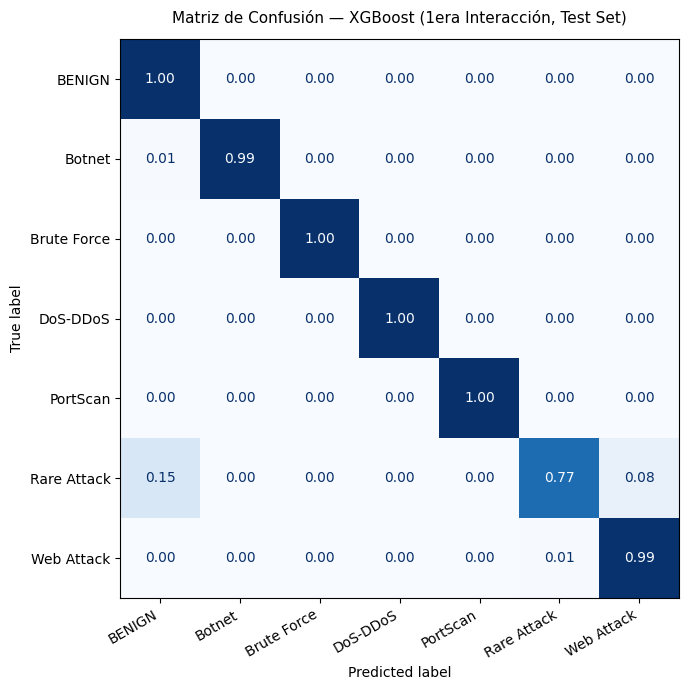

In [48]:
# Seleccionar mejor modelo según F1 Macro en CV
# Creamos un diccionario vinculando los resultados de CV y los objetos de los modelos
resultados_exp1 = {
    'Árbol de Decisión': (cv_dt_base, dt_base),
    'Random Forest': (cv_rf_base, rf_base),
    'XGBoost': (cv_xgb_base, xgb_base),
}

# Buscamos automáticamente el modelo con el promedio de F1 Macro más alto en CV
mejor_nombre_exp1 = max(
    resultados_exp1.keys(),
    key=lambda k: resultados_exp1[k][0]['test_f1_macro'].mean()
)
_, mejor_modelo_exp1 = resultados_exp1[mejor_nombre_exp1]

print(f"Mejor modelo de la 1era Interación: {mejor_nombre_exp1}")

# Entrenamos el mejor modelo con TODO X_train (unión de todos los folds)
# Nota: si el ganador es XGBoost, necesita los sample_weight calculados en 5.4
if mejor_nombre_exp1 == 'XGBoost':
    mejor_modelo_exp1.fit(X_train, y_train, sample_weight=pesos_train)
else:
    mejor_modelo_exp1.fit(X_train, y_train)

# Generamos las predicciones definitivas sobre el conjunto de Test
y_pred_exp1 = mejor_modelo_exp1.predict(X_test)

# Reporte completo de clasificación
reporte_dict = classification_report(
    y_test, y_pred_exp1,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True # Fix: ensure classification_report returns a dictionary
)
df_reporte = pd.DataFrame(reporte_dict).transpose()
print(f"\nREPORTE — {mejor_nombre_exp1} (Test Set)")
display(df_reporte.round(3))

# Matriz de confusión
graficar_confusion(
    y_test,
    y_pred_exp1,
    f'Matriz de Confusión — {mejor_nombre_exp1} (1era Interación, Test Set)',
    le
)


**Análisis de la Matriz de Confusión (XGBoost, Test Set):**

La matriz de confusión normalizada por fila muestra el **Recall por clase**: qué proporción de los ejemplos reales de cada clase el modelo clasificó correctamente.

Patrones esperados y su interpretación:

- **Diagonal alta en BENIGN y DoS/DDoS**: estas clases tienen miles de ejemplos de entrenamiento, el modelo las aprende sólidamente.
- **Diagonal alta en PortScan**: los ataques de escaneo tienen patrones de tráfico muy distintivos (muchas conexiones en ráfaga a múltiples puertos), fáciles de separar.
- **Confusión entre Brute Force y Web Attack**: ambos involucran intentos repetidos de autenticación HTTP, con features de red similares (mismos puertos destino, patrones de payload parecidos).
- **Confusión entre Botnet y Rare Attack**: ambas clases son muy pequeñas; el modelo puede confundir patrones de tráfico de botnet de baja intensidad con ataques raros de infiltración.
- **Celda (i, i) baja para Rare Attack**: la clase con menos muestras es la más difícil. Incluso con `sample_weight`, la señal de gradiente de estas pocas muestras puede ser insuficiente para separar bien esta clase.

# Segunda Interación - Aplicación de SMOTE

SMOTE es una técnica de sobremuestreo que equilibra los datasets generando datos sintéticos de la clase minoritaria, en lugar de simplemente duplicar filas (lo que causaría overfitting). Para crear estas nuevas muestras artificiales, utiliza el algoritmo k-NN para realizar una interpolación geométrica entre los datos reales más cercanos.

**Estrategia de Muestreo**

* k_neighbors=3 (Robustez): Se reduce el valor por defecto ($k=5$) a $k=3$ porque la clase 'Rare Attack' cuenta con muy pocas muestras. Esto reduce el requisito mínimo a 4 muestras por clase en el subset de entrenamiento, evitando que el código falle con un ValueError durante la validación cruzada.
* sampling_strategy Personalizada (Balance vs. Overfitting): En lugar de igualar todas las clases de forma masiva (lo que inflaría el dataset artificialmente), se definen topes controlados (e.g., 4,000 para Rare Attack y 12,000 para Botnet). Esto le da al modelo el volumen necesario para aprender a detectar los ataques minoritarios sin caer en un sobreajuste (overfitting) severo por exceso de datos sintéticos.

In [50]:
# Configurar SMOTE
# Definimos una estrategia de muestreo personalizada
estrategia_muestreo = {
    'Brute Force': 20000,
    'Web Attack': 12000,
    'Botnet': 12000,
    'Rare Attack': 4000
}

# 'mapeo' fue calculado en la sección 2.2: Lo usamos para traducir los nombres
# de clase a los códigos numéricos que usan y_train / y_balanceado
estrategia_muestreo_codificada = {
    mapeo[clase]: cantidad
    for clase, cantidad in estrategia_muestreo.items()
}

print("Estrategia de muestreo (códigos numéricos):")
for codigo, cantidad in estrategia_muestreo_codificada.items():
    print(f"  {le.inverse_transform([codigo])[0]} ({codigo}): {cantidad}")

Estrategia de muestreo (códigos numéricos):
  Brute Force (2): 20000
  Web Attack (6): 12000
  Botnet (1): 12000
  Rare Attack (5): 4000


## 6.1 SMOTE + Árbol de Decisión

In [51]:
# Usamos ImbPipeline para asegurar que SMOTE se aplique exclusivamente
# en el Train de cada fold, protegiendo el bloque de validación.
dt_smote = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=estrategia_muestreo_codificada, k_neighbors=3, random_state=42)),
    ('modelo', DecisionTreeClassifier(
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ))
])

# Ejecución de la validación cruzada en paralelo
cv_dt_smote = cross_validate(
    dt_smote, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    return_train_score=False,
    n_jobs=-1  # Distribuye los folds eficientemente entre todos los núcleos
)

mostrar_cv_resultados(cv_dt_smote, "Árbol de Decisión con SMOTE")

 Árbol de Decisión con SMOTE
  Recall Macro: 0.9560  (± 0.0187)
  Precision Macro: 0.8743  (± 0.0324)
  F1 Macro: 0.8937  (± 0.0340)
  Balanced Accuracy: 0.9560  (± 0.0187)
Tiempo promedio/fold: 19.4s


Al añadir SMOTE al árbol, el efecto más probable es una mejora en el Recall de las clases minoritarias a costa de posible reducción de Precision. El árbol ya tiene `class_weight='balanced'`, que ajusta los pesos internamente. Al combinar ambas técnicas (pesos + datos sintéticos), el modelo recibe una señal doble: datos adicionales de las clases minoritarias Y mayor penalización por errar en ellas.

Esto puede generar **sobredetección**: el modelo declara ataque ante cualquier ambigüedad, aumentando las falsas alarmas. El impacto en F1 Macro depende de cuál efecto domina.

## 6.2 SMOTE + Random Forest

In [52]:
# max_depth=20: Controla el crecimiento de los árboles para evitar sobreajuste
# n_estimators=100: Número de árboles en el bosque
# class_weight='balanced_subsample': Calcula los pesos basados en el bootstrap de cada árbol
rf_smote = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=estrategia_muestreo_codificada, k_neighbors=3, random_state=42)),
    ('modelo', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1  # Paraleliza el entrenamiento de los árboles internamente
    ))
])

# Ejecución de la validación cruzada
cv_rf_smote = cross_validate(
    rf_smote, X_train, y_train,
    cv=CV,
    scoring=SCORING,
    return_train_score=False,
    n_jobs=-1  # Distribuye los folds en paralelo
)

mostrar_cv_resultados(cv_rf_smote, "Random Forest con SMOTE")

 Random Forest con SMOTE
  Recall Macro: 0.9504  (± 0.0171)
  Precision Macro: 0.9701  (± 0.0122)
  F1 Macro: 0.9568  (± 0.0128)
  Balanced Accuracy: 0.9504  (± 0.0171)
Tiempo promedio/fold: 80.1s


Random Forest es el modelo que más se beneficia de SMOTE entre los tres:

- El mecanismo de bootstrap sampling de RF ya genera variedad en los datos de entrenamiento de cada árbol. Al añadir muestras sintéticas de clases minoritarias, algunos árboles del ensemble que antes no tenían ningún ejemplo de Botnet o Rare Attack en su bootstrap sample ahora sí los tienen.
- La robustez natural de RF a datos ruidosos ayuda a "absorber" las muestras sintéticas de SMOTE sin sobreajustarse a ellas.

## 6.3 SMOTE + XGBoost



In [53]:
# XGBoost no se integra de forma directa con cross_validate
# Por eso armamos manualmente el bucle de validación cruzada:
#  1. En cada fold, aplicamos SMOTE SOLO sobre el fold de entrenamiento.
#  2. Entrenamos XGBoost sobre los datos balanceados.
#  3. Evaluamos sobre el fold de validación ORIGINAL (sin SMOTE).

xgb_smote_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

metricas_xgb_smote = {'recall_macro': [], 'precision_macro': [], 'f1_macro': [], 'balanced_accuracy': [], 'fit_time': []}

for fold_idx, (idx_tr, idx_val) in enumerate(CV.split(X_train_arr, y_train_arr), start=1):
    modelo_fold = clone(xgb_smote_base)

    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]

    # SMOTE se aplica SOLO sobre el fold de entrenamiento
    smote_fold = SMOTE(
        sampling_strategy=estrategia_muestreo_codificada,
        k_neighbors=3,
        random_state=42
    )
    X_tr_bal, y_tr_bal = smote_fold.fit_resample(X_tr, y_tr)

    inicio = time.time()
    modelo_fold.fit(X_tr_bal, y_tr_bal)
    metricas_xgb_smote['fit_time'].append(time.time() - inicio)

    pred_val = modelo_fold.predict(X_val)

    metricas_xgb_smote['recall_macro'].append(recall_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['precision_macro'].append(precision_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['f1_macro'].append(f1_score(y_val, pred_val, average='macro'))
    metricas_xgb_smote['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred_val))

cv_xgb_smote = {
    'test_recall_macro': np.array(metricas_xgb_smote['recall_macro']),
    'test_precision_macro': np.array(metricas_xgb_smote['precision_macro']),
    'test_f1_macro': np.array(metricas_xgb_smote['f1_macro']),
    'test_balanced_accuracy': np.array(metricas_xgb_smote['balanced_accuracy']),
    'fit_time': np.array(metricas_xgb_smote['fit_time']),
}

mostrar_cv_resultados(cv_xgb_smote, "XGBoost con SMOTE")

 XGBoost con SMOTE
  Recall Macro: 0.9613  (± 0.0233)
  Precision Macro: 0.9898  (± 0.0073)
  F1 Macro: 0.9714  (± 0.0135)
  Balanced Accuracy: 0.9613  (± 0.0233)
Tiempo promedio/fold: 93.0s


A diferencia de RF, XGBoost puede ser más sensible a las muestras sintéticas porque el proceso de boosting puede "enfocarse" excesivamente en los puntos difíciles (incluyendo los sintéticos mal posicionados). Sin embargo, los parámetros `subsample=0.8` y `colsample_bytree=0.8` actúan como regularización implícita que mitiga esto.

## 6.4 Comparativa

In [54]:
# Tabla comparativa
comparativa_12 = pd.DataFrame({
    'Modelo': [
        'DT — class_weight', 'DT — SMOTE',
        'RF — class_weight', 'RF — SMOTE',
        'XGBoost — class_weight', 'XGBoost — SMOTE'
    ],
    'Recall Macro': [
        cv_dt_base['test_recall_macro'].mean(), cv_dt_smote['test_recall_macro'].mean(),
        cv_rf_base['test_recall_macro'].mean(), cv_rf_smote['test_recall_macro'].mean(),
        cv_xgb_base['test_recall_macro'].mean(), cv_xgb_smote['test_recall_macro'].mean()
    ],
    'Precision Macro': [
        cv_dt_base['test_precision_macro'].mean(), cv_dt_smote['test_precision_macro'].mean(),
        cv_rf_base['test_precision_macro'].mean(), cv_rf_smote['test_precision_macro'].mean(),
        cv_xgb_base['test_precision_macro'].mean(), cv_xgb_smote['test_precision_macro'].mean()
    ],
    'F1 Macro': [
        cv_dt_base['test_f1_macro'].mean(), cv_dt_smote['test_f1_macro'].mean(),
        cv_rf_base['test_f1_macro'].mean(), cv_rf_smote['test_f1_macro'].mean(),
        cv_xgb_base['test_f1_macro'].mean(), cv_xgb_smote['test_f1_macro'].mean()
    ],
    'Balanced Accuracy': [
        cv_dt_base['test_balanced_accuracy'].mean(), cv_dt_smote['test_balanced_accuracy'].mean(),
        cv_rf_base['test_balanced_accuracy'].mean(), cv_rf_smote['test_balanced_accuracy'].mean(),
        cv_xgb_base['test_balanced_accuracy'].mean(), cv_xgb_smote['test_balanced_accuracy'].mean()
    ],
    'Tiempo/fold (s)': [
        cv_dt_base['fit_time'].mean(), cv_dt_smote['fit_time'].mean(),
        cv_rf_base['fit_time'].mean(), cv_rf_smote['fit_time'].mean(),
        cv_xgb_base['fit_time'].mean(), cv_xgb_smote['fit_time'].mean()
    ],
    'Estrategia': [
        'class_weight', 'SMOTE',
        'class_weight', 'SMOTE',
        'class_weight', 'SMOTE'
    ]
})

print("Comparativa 1ra Interación (class_weight) vs 2da Interación (SMOTE)")
print()
display(comparativa_12.set_index('Modelo').round(4))

Comparativa 1ra Interacción (class_weight) vs 2da Interacción (SMOTE)



,Recall Macro,Precision Macro,F1 Macro,Balanced Accuracy,Tiempo/fold (s),Estrategia
Modelo,,,,,,
DT — class_weight,0.9557,0.9162,0.9314,0.9557,9.2192,class_weight
DT — SMOTE,0.9560,0.8743,0.8937,0.9560,19.4267,SMOTE
RF — class_weight,0.9327,0.9894,0.9508,0.9327,67.9161,class_weight
RF — SMOTE,0.9504,0.9701,0.9568,0.9504,80.1447,SMOTE
XGBoost — class_weight,0.9752,0.9886,0.9798,0.9752,57.5023,class_weight
XGBoost — SMOTE,0.9613,0.9898,0.9714,0.9613,93.0161,SMOTE


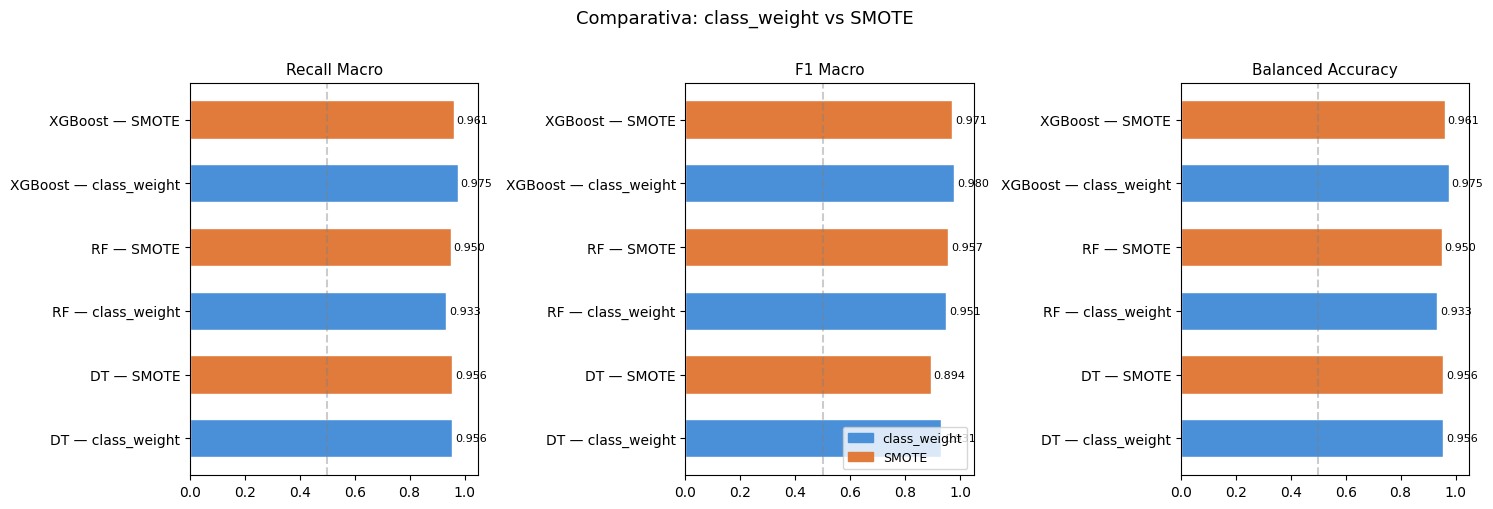

In [55]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_plot = ['Recall Macro', 'F1 Macro', 'Balanced Accuracy']

for ax, metrica in zip(axes, metricas_plot):
    colores = ['#4A90D9' if e == 'class_weight' else '#E07B3B'
               for e in comparativa_12['Estrategia']]
    bars = ax.barh(comparativa_12['Modelo'], comparativa_12[metrica],
                   color=colores, edgecolor='white', height=0.6)
    ax.set_xlim(0, 1.05)
    ax.set_title(metrica, fontsize=11)
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.4)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=8)

# Leyenda manual
leyenda = [Patch(color='#4A90D9', label='class_weight'),
           Patch(color='#E07B3B', label='SMOTE')]
axes[1].legend(handles=leyenda, loc='lower right', fontsize=9)

plt.suptitle("Comparativa: class_weight vs SMOTE", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 7. Selección del Modelo Final y Evaluación en el Test Set

In [56]:
# Diccionario con todos los resultados de CV (1ra y 2da Interación)
resultados_finales = {
    'DT — class_weight': (cv_dt_base, dt_base, False),
    'DT — SMOTE': (cv_dt_smote, dt_smote, True),
    'RF — class_weight': (cv_rf_base, rf_base, False),
    'RF — SMOTE': (cv_rf_smote, rf_smote, True),
    'XGBoost — class_weight': (cv_xgb_base, xgb_base, False),
    'XGBoost — SMOTE': (cv_xgb_smote, xgb_smote_base, True),
}

# Elegimos el modelo con mayor F1 Macro promedio en CV
mejor_nombre_final = max(
    resultados_finales.keys(),
    key=lambda k: resultados_finales[k][0]['test_f1_macro'].mean()
)
cv_ganador, modelo_ganador, usa_smote = resultados_finales[mejor_nombre_final]

print(f"Modelo ganador (por F1 Macro en CV): {mejor_nombre_final}")
print(f" F1 Macro (CV): {cv_ganador['test_f1_macro'].mean():.4f} (± {cv_ganador['test_f1_macro'].std():.4f})")
print(f" Recall Macro (CV): {cv_ganador['test_recall_macro'].mean():.4f}")
print(f" Precision Macro (CV): {cv_ganador['test_precision_macro'].mean():.4f}")
print(f" Balanced Accuracy (CV): {cv_ganador['test_balanced_accuracy'].mean():.4f}")


Modelo ganador (por F1 Macro en CV): XGBoost — class_weight
 F1 Macro (CV): 0.9798 (± 0.0098)
 Recall Macro (CV): 0.9752
 Precision Macro (CV): 0.9886
 Balanced Accuracy (CV): 0.9752
